<a href="https://colab.research.google.com/github/cgm2179/Branch_2_Diffusion_Transformer_efficiency_for_small_model/blob/main/Section%206%20-%20Cameron's%20Version/regime%201/05_three_factor_noisy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# §6 MLP regime 1 / Three-factor **noisy** (cos≈0.01) — regression
Very few probes, most steps.

## Step 0 — Setup

In [25]:
import os, time, math, json
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('torch', torch.__version__, '| device:', device)
if device == 'cpu':
    print('WARNING: no GPU. Built for an A100 Colab runtime; set SMOKE=True to sanity-check on CPU.')

torch 2.11.0+cu128 | device: cuda


## Config

In [26]:
METHOD = 'three_factor_noisy'
SIGMA = 1e-2
TARGET_COS = 0.01   # M chosen so cos(g_hat, grad) ~ this
CHUNK_PROBES = 512
LR_LOCAL = 0.05
MOMENTUM = 0.9
CLIP_GRAD_NORM = 1.0
METHOD_CFG = dict(SIGMA=SIGMA, TARGET_COS=TARGET_COS, CHUNK_PROBES=CHUNK_PROBES, LR_LOCAL=LR_LOCAL, MOMENTUM=MOMENTUM, CLIP_GRAD_NORM=CLIP_GRAD_NORM)


# =============================== CONFIG (shared across the 5 methods) ===============================
# Student MLP (~1.01M params) regresses a fixed random teacher. Same P as the §8 ViT -> cos sweep comparable.
IN_DIM, OUT_DIM = 64, 16
HIDDEN          = (1024, 896)     # deep tanh; the build cell prints exact P (target ~1.01M)
TEACHER_HID     = 128             # fixed random teacher: IN_DIM -> TEACHER_HID -> OUT_DIM

TIME_BUDGET_HOURS = 1.5           # equal wall-clock across methods
BATCH             = 256           # fresh x ~ N(0,I) per step (teacher gives the target)
SEED              = 0             # same teacher + same student init across all methods
EVAL_N, EVAL_BATCH = 4096, 1024   # fixed held-out eval set from the teacher

LOG_EVERY_SEC, CKPT_EVERY_SEC, PLOT_EVERY_SEC, HEARTBEAT_EVERY_SEC = 30, 120, 1800, 60
USE_DRIVE, DRIVE_SUBDIR = True, 'Section6_regime1'


SMOKE = False
if SMOKE:                                     # ~20 s CPU check
    IN_DIM, OUT_DIM, HIDDEN, TEACHER_HID = 16, 4, (32,), 16
    TIME_BUDGET_HOURS = 20/3600
    LOG_EVERY_SEC, CKPT_EVERY_SEC, PLOT_EVERY_SEC, HEARTBEAT_EVERY_SEC = 1, 2, 999, 1
    EVAL_N, EVAL_BATCH, USE_DRIVE = 256, 256, False
# ===================================================================================================

## Step 1 — Storage (Drive) + paths

In [27]:
if USE_DRIVE:
    try:
        from google.colab import drive; drive.mount('/content/drive')
        STORE = os.path.join('/content/drive/MyDrive', DRIVE_SUBDIR)
    except Exception as e:
        print('Drive mount failed -> local /content (will NOT survive disconnect):', e)
        STORE = os.path.join('/content', DRIVE_SUBDIR)
else:
    STORE = os.path.join('.', DRIVE_SUBDIR)
RESULTS_DIR = os.path.join(STORE, 'results')
CKPT_DIR    = os.path.join(STORE, 'checkpoints')
FIG_DIR     = os.path.join(STORE, 'figures')
for d in (RESULTS_DIR, CKPT_DIR, FIG_DIR): os.makedirs(d, exist_ok=True)
RESULTS_PATH = os.path.join(RESULTS_DIR, f'{METHOD}.json')
CKPT_PATH    = os.path.join(CKPT_DIR,    f'{METHOD}.pt')
print('storing under:', STORE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
storing under: /content/drive/MyDrive/Section6_regime1


## Step 2 — Model (deep tanh MLP)

In [28]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    """Deep tanh MLP. vmap-safe (Linear + tanh only)."""
    def __init__(self, in_dim, hidden, out_dim):
        super().__init__()
        dims = [in_dim] + list(hidden) + [out_dim]
        self.layers = nn.ModuleList([nn.Linear(dims[i], dims[i+1]) for i in range(len(dims)-1)])
    def forward(self, x):
        for i, lyr in enumerate(self.layers):
            x = lyr(x)
            if i < len(self.layers) - 1:
                x = torch.tanh(x)
        return x

## Step 3 — Teacher + data (student/teacher regression)

In [29]:
# Fixed random teacher defines the target y = teacher(x); deterministic per SEED (identical across methods).
torch.manual_seed(SEED)
teacher = nn.Sequential(nn.Linear(IN_DIM, TEACHER_HID), nn.Tanh(), nn.Linear(TEACHER_HID, OUT_DIM)).to(device)
for p in teacher.parameters():
    p.requires_grad_(False)

@torch.no_grad()
def _teacher(x):
    return teacher(x)

Xte = torch.randn(EVAL_N, IN_DIM, device=device)
Yte = _teacher(Xte)
Yte_var = Yte.var().item()

def fresh_batch(n):
    x = torch.randn(n, IN_DIM, device=device)
    return x, _teacher(x)
print(f'teacher {IN_DIM}->{TEACHER_HID}->{OUT_DIM} | eval set {tuple(Xte.shape)} | Var(Y)={Yte_var:.4f}')

teacher 64->128->16 | eval set (4096, 64) | Var(Y)=0.0774


## Step 4 — Build student + budget

In [30]:
torch.manual_seed(SEED)
model = MLP(IN_DIM, HIDDEN, OUT_DIM).to(device)     # the "student" (functional base for three-factor)
P = sum(p.numel() for p in model.parameters())
Mstar = math.ceil((P + 1) / 3)
if METHOD.startswith('three_factor'):
    M = max(1, round(TARGET_COS**2 * (P + 1) / (1 - TARGET_COS**2)))
    got = (M / (M + P + 1))**0.5
    print(f'target cos = {TARGET_COS} -> M = {M:,} probes/step (actual cos = {got:.4f}); M*(cos=0.5) = {Mstar:,}')
else:
    M = 0
print(f'METHOD = {METHOD} | student P = {P:,} | in={IN_DIM} out={OUT_DIM} hidden={HIDDEN}')
CFG = dict(METHOD=METHOD, SEED=SEED, IN_DIM=IN_DIM, OUT_DIM=OUT_DIM, HIDDEN=list(HIDDEN), BATCH=BATCH,
           TIME_BUDGET_HOURS=TIME_BUDGET_HOURS)
CFG.update(METHOD_CFG)
if METHOD.startswith('three_factor'):
    CFG['M'] = M
assert P < 3_000_000, 'student too large for a from-scratch three-factor run (cost ~ P^2 at the clean budget).'

target cos = 0.01 -> M = 100 probes/step (actual cos = 0.0100); M*(cos=0.5) = 333,105
METHOD = three_factor_noisy | student P = 999,312 | in=64 out=16 hidden=(1024, 896)


## Step 5 — Probe estimator (vmap antithetic, MSE)

In [31]:
from torch.func import functional_call, vmap
base_buffers = {k: v.detach() for k, v in model.named_buffers()}     # MLP has none -> {}

def get_params(m):
    return {k: v.detach().clone() for k, v in m.named_parameters()}

def loss_at(params, x, y):
    return F.mse_loss(functional_call(model, (params, base_buffers), (x,)), y)

_vloss = vmap(loss_at, in_dims=(0, None, None))

def estimate_grad(params, x, y, M, sigma, chunk):
    g = {k: torch.zeros_like(v) for k, v in params.items()}
    done = 0
    while done < M:
        m = min(chunk, M - done)
        xi = {k: torch.randn((m,) + v.shape, device=v.device, dtype=v.dtype) for k, v in params.items()}
        pp = {k: params[k].unsqueeze(0) + sigma * xi[k] for k in params}
        pm = {k: params[k].unsqueeze(0) - sigma * xi[k] for k in params}
        score = (_vloss(pp, x, y) - _vloss(pm, x, y)) / (2 * sigma)
        for k in params:
            g[k] += torch.tensordot(score, xi[k], dims=([0], [0]))
        done += m
    return {k: g[k] / M for k in g}

## Step 6 — Trainer

In [32]:
params   = get_params(model)                       # seeded student init
velocity = {k: torch.zeros_like(v) for k, v in params.items()}
def forward_fn(x): return functional_call(model, (params, base_buffers), (x,))
def train_step():
    xb, yb = fresh_batch(BATCH)
    g = estimate_grad(params, xb, yb, M, SIGMA, CHUNK_PROBES)
    gn = math.sqrt(sum(float((v*v).sum()) for v in g.values()))
    if CLIP_GRAD_NORM and gn > CLIP_GRAD_NORM:
        s = CLIP_GRAD_NORM / (gn + 1e-12)
        for k in g: g[k].mul_(s)
    with torch.no_grad():
        for k in params:
            velocity[k] = MOMENTUM * velocity[k] + g[k]; params[k] -= LR_LOCAL * velocity[k]
        return F.mse_loss(forward_fn(xb), yb).item()
def ckpt_state():      return {'params': params, 'velocity': velocity}
def load_ckpt_state(d):
    for k in params: params[k].copy_(d['params'][k]); velocity[k].copy_(d['velocity'][k])

## Step 7 — Eval / checkpoint / live-plot

In [33]:
@torch.no_grad()
def eval_metrics():
    se = 0.0; ne = 0
    for i in range(0, Xte.shape[0], EVAL_BATCH):
        pred = forward_fn(Xte[i:i+EVAL_BATCH]); yb = Yte[i:i+EVAL_BATCH]
        se += F.mse_loss(pred, yb, reduction='sum').item(); ne += yb.numel()
    mse = se / ne
    r2 = 1.0 - mse / max(Yte_var, 1e-12)      # fraction of variance explained (0..1, higher better)
    return mse, r2

In [34]:
def _atomic_save(obj, path):
    tmp = path + '.tmp'; torch.save(obj, tmp); os.replace(tmp, path)

def save_checkpoint(step, elapsed, logs):
    _atomic_save({'loop': {'step': step, 'elapsed_sec': elapsed, 'logs': logs},
                  'method': ckpt_state(), 'config': CFG}, CKPT_PATH)

def maybe_resume():
    if os.path.exists(CKPT_PATH):
        d = torch.load(CKPT_PATH, map_location=device)
        load_ckpt_state(d['method']); L = d['loop']
        print(f'[resume] {METHOD}: step {L["step"]:,}, elapsed {L["elapsed_sec"]/3600:.2f}h -> continuing.')
        return L['step'], L['elapsed_sec'], L['logs']
    return 0, 0.0, []

In [35]:
def live_plot(logs, final=False):
    if not logs: return
    hrs = [l[0]/3600 for l in logs]; tr=[l[3] for l in logs]; te=[l[4] for l in logs]; r2=[l[5] for l in logs]
    if not final: clear_output(wait=True)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(hrs, tr, '-', color='#999', label='train MSE'); ax[0].plot(hrs, te, 'o-', color='#C62828', label='test MSE')
    ax[0].set_xlabel('elapsed hours'); ax[0].set_ylabel('MSE'); ax[0].set_yscale('log')
    ax[0].set_title(f'{METHOD}: MSE vs time'); ax[0].legend()
    ax[1].plot(hrs, r2, 'o-', color='#1F3864'); ax[1].set_xlabel('elapsed hours'); ax[1].set_ylabel('R^2'); ax[1].set_title('R^2 vs time')
    plt.tight_layout()
    try: fig.savefig(os.path.join(FIG_DIR, f'{METHOD}_progress.png'), dpi=90)
    except Exception as e: print('savefig failed:', e)
    plt.show()
    last = logs[-1]; print(f'[h={last[0]/3600:.2f}] step={last[1]:,} test_mse={last[4]:.5f} R2={last[5]:.3f}')

## Step 8 — Train (equal wall-clock, heartbeat) + save results

[resume] three_factor_noisy: step 323,459, elapsed 1.07h -> continuing.
[three_factor_noisy] step 1 = 0.01s -> ~373,171 steps fit the budget.
[three_factor_noisy] h=1.08 step=328,513 train=0.04379 test_mse=0.04272 R2=0.448
[three_factor_noisy] h=1.10 step=333,569 train=0.04041 test_mse=0.04190 R2=0.459
[three_factor_noisy] h=1.12 step=338,619 train=0.04335 test_mse=0.04350 R2=0.438
[three_factor_noisy] h=1.13 step=343,677 train=0.04246 test_mse=0.04326 R2=0.441
[three_factor_noisy] h=1.15 step=348,735 train=0.04374 test_mse=0.04218 R2=0.455
[three_factor_noisy] h=1.17 step=353,786 train=0.04217 test_mse=0.04345 R2=0.439
[three_factor_noisy] h=1.18 step=358,848 train=0.04311 test_mse=0.04332 R2=0.440
[three_factor_noisy] h=1.20 step=363,906 train=0.04351 test_mse=0.04337 R2=0.440
[three_factor_noisy] h=1.22 step=368,965 train=0.04304 test_mse=0.04493 R2=0.419
[three_factor_noisy] h=1.23 step=374,012 train=0.04416 test_mse=0.04427 R2=0.428
[three_factor_noisy] h=1.25 step=379,071 train=0

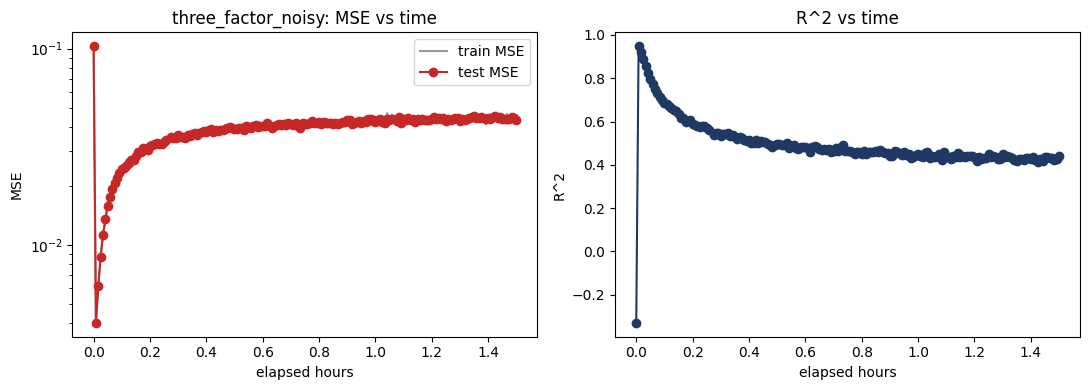

[h=1.50] step=454,775 test_mse=0.04341 R2=0.439
wrote /content/drive/MyDrive/Section6_regime1/results/three_factor_noisy.json
DONE three_factor_noisy: 454,775 steps, 1.50h, final R2 0.439, best MSE 0.00400


In [36]:
def write_results(step, elapsed, logs):
    te = [l[4] for l in logs]; r2 = [l[5] for l in logs]
    summary = dict(initial_mse=logs[0][4], final_mse=logs[-1][4], best_mse=min(te),
                   reduction_pct=100*(logs[0][4]-min(te))/max(logs[0][4], 1e-12),
                   final_r2=logs[-1][5], best_r2=max(r2))
    peak = torch.cuda.max_memory_allocated()/1e6 if device == 'cuda' else float('nan')
    out = dict(meta=dict(method=METHOD, device=device, seed=SEED, P=P, config=CFG, note='all MEASURED-here',
                         wall_clock_sec=elapsed, total_steps=step, samples=step*BATCH, peak_mem_mb=peak),
               curve=dict(t_sec=[l[0] for l in logs], step=[l[1] for l in logs], samples=[l[2] for l in logs],
                          train_mse=[l[3] for l in logs], test_mse=te, test_r2=r2),
               summary=summary)
    with open(RESULTS_PATH, 'w') as f: json.dump(out, f, indent=2)
    print('wrote', RESULTS_PATH)

def run():
    step, elapsed0, logs = maybe_resume()
    t0 = time.time(); budget = TIME_BUDGET_HOURS*3600
    last_ckpt = last_plot = last_log = last_beat = elapsed0
    if not logs:
        m0, a0 = eval_metrics(); logs.append((elapsed0, step, 0, m0, m0, a0))
    tl = logs[-1][3]; printed = False
    while True:
        elapsed = elapsed0 + (time.time() - t0)
        if elapsed >= budget: break
        tl = train_step(); step += 1
        if not printed:
            dt = time.time() - t0
            print(f'[{METHOD}] step 1 = {dt:.2f}s -> ~{int(budget/max(dt,1e-9)):,} steps fit the budget.', flush=True); printed = True
        if elapsed - last_log >= LOG_EVERY_SEC:
            mse, r2 = eval_metrics(); logs.append((elapsed, step, step*BATCH, tl, mse, r2)); last_log = elapsed
        if elapsed - last_beat >= HEARTBEAT_EVERY_SEC:
            L = logs[-1]
            print(f'[{METHOD}] h={elapsed/3600:.2f} step={step:,} train={L[3]:.5f} test_mse={L[4]:.5f} R2={L[5]:.3f}', flush=True)
            last_beat = elapsed
        if elapsed - last_ckpt >= CKPT_EVERY_SEC:
            save_checkpoint(step, elapsed, logs); last_ckpt = elapsed
        if elapsed - last_plot >= PLOT_EVERY_SEC:
            live_plot(logs); last_plot = elapsed
    elapsed = elapsed0 + (time.time() - t0)
    mse, r2 = eval_metrics(); logs.append((elapsed, step, step*BATCH, tl, mse, r2))
    save_checkpoint(step, elapsed, logs); live_plot(logs, final=True); write_results(step, elapsed, logs)
    print(f'DONE {METHOD}: {step:,} steps, {elapsed/3600:.2f}h, final R2 {r2:.3f}, best MSE {min(l[4] for l in logs):.5f}')

run()

## How to run
- `SMOKE=True` first (~20 s), then `False` → Runtime → Run all.
- Equal wall-clock; heartbeat every ~60 s; disconnect-safe (own checkpoint, auto-resume); writes `results/<method>.json`. Same teacher + student init (SEED) across all 5 methods → fair. Compare in `06_compare_results.ipynb`.